In [1]:
# Import all functions from the required modules
from cordo_sherpa_module import *
from cordo_chimere_module import *
from expo_functions_module import *
from mortality_chimere_module import *
from cessation_lag_module import *
from association_module import *
from morbidity_chimere_module import *
print("Successfully loaded all modules")

loaded defined RR values
loaded defined RR values
Successfully loaded Cessation Lag functions
Successfully loaded all modules


In [2]:
# Paths to the files
path_fichier_shp = "data/2-output-data/donnees_shp"
title_shp = "donnees_insee_iris"
path_fichier_pourcents = "data/2-output-data"
title_pourcents = "pourcents"

# Load the concentration points
conc_points = coordo_sherpa(sc="s1", pol="ug_NO2", year=2019)

# Load the exported data
donnees_exportees = gpd.read_file(os.path.join(path_fichier_shp, f"{title_shp}.shp"))

# Transform the CRS of the exported data to match the concentration points
donnees_exportees_transformed = donnees_exportees.to_crs(epsg=conc_points.crs.to_epsg())

# Check if CRSs are the same
if conc_points.crs == donnees_exportees_transformed.crs:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are the same.")
else:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are different.")

Concentrations in 2019 and 2019 are calculated for the pollutant 'ug_no2' (s1).
CRS for conc_points_transformed and donnees_exportees_transformed are the same.


In [3]:
import os
# Define paths for shapefiles
path_fichier_shp = "data/2-output-data/donnees_shp"
path_fichier_shp_1 = "data/2-output-data/donnees_shp_1"
path_fichier_shp_2 = "data/2-output-data/donnees_shp_2"
path_fichier_shp_3 = "data/2-output-data/donnees_shp_3"
path_fichier_pourcents = "data/2-output-data"

# Titles for INSEE Data
title_shp = "donnees_insee_iris"
title_shp_1 = "donnees_insee_iris_toutage_1"
title_shp_2 = "donnees_insee_iris_toutage_2"
title_shp_3 = "donnees_insee_iris_toutage_3"
title_pourcents = "pourcents"

# Read shapefiles into GeoDataFrames
donnees_shp_1 = gpd.read_file(os.path.join(path_fichier_shp_1, f"{title_shp_1}.shp"))
donnees_shp_2 = gpd.read_file(os.path.join(path_fichier_shp_2, f"{title_shp_2}.shp"))
donnees_shp_3 = gpd.read_file(os.path.join(path_fichier_shp_3, f"{title_shp_3}.shp"))

# Combine the three GeoDataFrames
donnees_merged = gpd.GeoDataFrame(pd.concat([donnees_shp_1, donnees_shp_2, donnees_shp_3], ignore_index=True))
print(donnees_merged.head())

grille_combinee = gpd.read_file(os.path.join(path_fichier_pourcents, f"{title_pourcents}.shp"))
grille_combinee = grille_combinee.to_crs(conc_points.crs)

     iriscod irisname comcod comname depcod depname  regcod           regname  \
0  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
1  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
2  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
3  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   
4  721910000    Mayet  72191   Mayet     72  Sarthe      52  Pays de la Loire   

   age    pop2019    pop2030    pop2050  mort2019  mort2030  mort2050  \
0    0  31.979362  30.560224  28.974134  0.114652  0.101665  0.085457   
1    1  32.735555  30.384526  29.200275  0.018369  0.016510  0.014105   
2    2  33.511730  30.265005  29.417218  0.008333  0.007299  0.006310   
3    3  34.431724  30.206960  29.615683  0.005018  0.004605  0.004083   
4    4  35.587474  30.214303  29.787011  0.003853  0.003519  0.003135   

                                            geometry  
0  POLYGON ((497887

In [4]:
#Function to compute the exposure change from the anchor years and pre-defined functions
#Can not be shifted to a module as it relies on the global variables defined in this notebook (e.g. ANCHOR_YEARS,CHIMERE functions etc etc.)
def build_exposure_cache_for_anchors(scenario, pollutant, donnees_exportees_transformed, grille_combinee):
    expo_cache = {}
    for y in ANCHOR_YEARS:
        logging.info(f"[ANCHOR] Computing exposure: Scenario={scenario}, Pollutant={pollutant}, Year={y}")

        conc_points = coordo_chimere(pollutant, year=y, SC=scenario.upper())
        conc_points = conc_points.to_crs(donnees_exportees_transformed.crs)

        conc_chimere = coordo_ineris_chimere(pollutant, year="2019")
        conc_chimere = conc_chimere.to_crs(donnees_exportees_transformed.crs)

        conc_corrige = correction_chimere(conc_points, conc_chimere)
        expo_cache[int(y)] = expo(donnees_exportees_transformed, conc_corrige, grille_combinee)

    return expo_cache

In [16]:
import os
import logging
import warnings
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

# Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Task summary (updated):
# 1) Compute cessation-lag weights using two methods (COMEAP + linear)
# 2) Compute exposure change using linear interpolation between anchor years
# 3) Compute RR change with exposure using RR_MORTALITY_MAP (per UNIT_CHANGE)
# 4) Compute adjusted RR series (3 variants): COMEAP EF, Linear EF, and No-lag EF
#    Keep exposure constant from 2010..2019 inclusive (no exposure change, no policy intervention)

# Define scenarios, pollutants, and years
# run one-by-one to avoid memory issues
scenarios = ["s1", "s2", "s3", "s4"]
pollutants = ["ug_PM25_RH50"]  # ["ug_PM25_RH50", "ug_NO2"]
years = list(range(2010, 2070))
ANCHOR_YEARS = [2019, 2030, 2050]

def _validate_anchor_years(anchor_years):
    anchor_years = sorted(set(int(y) for y in anchor_years))
    if len(anchor_years) < 2:
        raise ValueError("Need at least two anchor years to interpolate.")
    return anchor_years

def _resolve_rr_key(pollutant_key, rr_map):
    k = str(pollutant_key).strip()
    if k in rr_map:
        return k

    kl = k.lower()
    for kk in rr_map.keys():
        if str(kk).strip().lower() == kl:
            return kk

    raise KeyError(f"{pollutant_key} not found in RR_MORTALITY_MAP. Available: {list(rr_map.keys())}")

ANCHOR_YEARS = _validate_anchor_years(ANCHOR_YEARS)
# Align CRS of shapefiles
target_crs = donnees_exportees_transformed.crs
donnees_exportees_transformed = donnees_exportees_transformed.to_crs(target_crs)
grille_combinee = grille_combinee.to_crs(target_crs)

# Baseline year for lag + exposure-change anchoring
BASELINE_YEAR = int(globals().get("LAG_BASE_YEAR", 2019))

# Apply cessation-lag weights over 20 years (both COMEAP and Linear lag)
LAG_YEARS = 20
delay_weights_comeap, frac_comeap, delay_weights_linear, frac_linear = generate_cessation_lag_fractions(
    base_year=BASELINE_YEAR, eval_years=years, lag_years=LAG_YEARS
)

# Keep exposure constant from 2010..2019 inclusive (no exposure change)
years_arr = np.asarray(years, dtype=int)
mask_pre = years_arr <= int(BASELINE_YEAR)

# Ensure effect fractions represent "realization after baseline": 0 up to baseline year
frac_comeap = np.asarray(frac_comeap, dtype=float)
frac_linear = np.asarray(frac_linear, dtype=float)
frac_comeap[mask_pre] = 0.0
frac_linear[mask_pre] = 0.0

# Use mapped RR for mortality (assumed RR per 10 ug/m3 unless you change UNIT_CHANGE)
UNIT_CHANGE = 10.0
def af_from_rr_delta(rr_per_unit: float, delta_exposure: np.ndarray, unit_change: float = 10.0) -> np.ndarray:
    """
    AF consistent with immediate-impact formula:
        AF = 1 - exp(-log(RR_per_unit) * delta_exposure / unit_change)
    """
    delta_exposure = np.asarray(delta_exposure, dtype=float)
    return 1.0 - np.exp(-np.log(rr_per_unit) * (delta_exposure / float(unit_change)))

def af_from_rr_abs(rr_abs: np.ndarray) -> np.ndarray:
    """
    Standard AF from an absolute RR:
        AF = (RR - 1)/RR
    This is useful if you want AF relative to a counterfactual RR=1.
    """
    rr_abs = np.asarray(rr_abs, dtype=float)
    return (rr_abs - 1.0) / rr_abs


plot_rows = []
for scenario in scenarios:
    for pollutant in pollutants:
        rr_key = _resolve_rr_key(pollutant, RR_MORTALITY_MAP_Main)
        rr_per_unit, rr_low, rr_high = RR_MORTALITY_MAP_Main[rr_key]
        rr_per_unit = float(rr_per_unit)

        print("pollutant:", pollutant, "rr_key:", rr_key)
        print("tuple:", RR_MORTALITY_MAP_Main[rr_key])
        print("rr_per_unit:", rr_per_unit, "rr_low:", rr_low, "rr_high:", rr_high)

        expo_cache = build_exposure_cache_for_anchors(
            scenario, pollutant, donnees_exportees_transformed, grille_combinee
        )
        anchor_means = exposure_mean_from_cache(expo_cache, pollutant)

        expo_linear = interpolate_exposure_means_linear(years, anchor_means)

        # Baseline exposure level
        if BASELINE_YEAR not in years:
            raise ValueError(f"BASELINE_YEAR={BASELINE_YEAR} must be included in `years`.")
        base_idx = int(list(years).index(BASELINE_YEAR))
        base_expo = float(anchor_means.get(BASELINE_YEAR, float(expo_linear[base_idx])))

        # Enforce constant exposure for 2010..2019 inclusive
        expo_linear = np.asarray(expo_linear, dtype=float)
        expo_linear[mask_pre] = float(base_expo)

        # Absolute RR level at baseline exposure (reference depends on rr_from_exposure_change implementation)
        rr_base_abs = float(
            rr_from_exposure_change(
                exposure_year=base_expo,
                exposure_base=None,
                rr_per_unit=rr_per_unit,
                unit_change=UNIT_CHANGE,
            )
        )

        # Absolute RR series from exposure levels (reference only)
        rr_full_linear = rr_from_exposure_change(
            exposure_year=expo_linear,
            exposure_base=None,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )

        # RR change relative to baseline exposure (RR=1 at baseline year by construction)
        rr_change_linear = rr_from_exposure_change(
            exposure_year=expo_linear,
            exposure_base=base_expo,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )

        # Apply cessation-lag to RR CHANGE (then re-anchor to baseline absolute RR)
        rr_change_adj_comeap = adjusted_rr_with_cessation_lag(rr_change_linear, frac_comeap)
        rr_change_adj_linear = adjusted_rr_with_cessation_lag(rr_change_linear, frac_linear)

        rr_adj_linear_comeap = rr_base_abs * np.asarray(rr_change_adj_comeap, dtype=float)
        rr_adj_linear_linlag = rr_base_abs * np.asarray(rr_change_adj_linear, dtype=float)

        # RR without any lags (immediate realization of exposure change)
        rr_adj_no_lag = rr_base_abs * np.asarray(rr_change_linear, dtype=float)

        # Exposure change relative to baseline exposure
        delta_exposure = np.asarray(expo_linear, dtype=float) - float(base_expo)

        # ---------------------------------------------------------------------
        # AF computations (two versions)
        #
        # 1) AF_delta_* is AF based on exposure DELTA relative to baseline exposure.
        #    This matches immediate impact formula:
        #       AF = 1 - exp(-log(RR) * deltaC / 10)
        #    - At baseline year deltaC=0 => AF_delta = 0.
        #    - After a reduction (deltaC < 0) => AF_delta becomes negative (benefit).
        # 2) AF_abs_* is AF computed from the ABSOLUTE RR series:
        #       AF = (RR - 1)/RR
        #    - This is *not* baseline-normalized; it’s relative to RR=1 counterfactual.
        # For multipliers to apply to "avoided impacts vs baseline year",
        # AF_delta_* is typically the more consistent quantity.
        # ---------------------------------------------------------------------
        af_delta_no_lag = af_from_rr_delta(rr_per_unit=rr_per_unit, delta_exposure=delta_exposure, unit_change=UNIT_CHANGE)
        af_delta_lag_comeap = af_from_rr_delta(
            rr_per_unit=rr_per_unit,
            # lagged *effective* delta exposure implied by the lagged RR-change:
            # Since rr_change = exp(log(RR_per_unit) * deltaC / UNIT_CHANGE),
            # we can invert deltaC = UNIT_CHANGE * log(rr_change) / log(RR_per_unit).
            delta_exposure=(UNIT_CHANGE * np.log(np.asarray(rr_change_adj_comeap, dtype=float)) / np.log(rr_per_unit)),
            unit_change=UNIT_CHANGE,
        )
        af_delta_lag_linear = af_from_rr_delta(
            rr_per_unit=rr_per_unit,
            delta_exposure=(UNIT_CHANGE * np.log(np.asarray(rr_change_adj_linear, dtype=float)) / np.log(rr_per_unit)),
            unit_change=UNIT_CHANGE,
        )

        af_abs_no_lag = af_from_rr_abs(rr_adj_no_lag)
        af_abs_lag_comeap = af_from_rr_abs(rr_adj_linear_comeap)
        af_abs_lag_linear = af_from_rr_abs(rr_adj_linear_linlag)

        for idx, (y, e_lin) in enumerate(zip(years, expo_linear)):
            plot_rows.append(
                {
                    "scenario": scenario,
                    "pollutant": pollutant,
                    "year": int(y),
                    "baseline_year": int(BASELINE_YEAR),
                    "baseline_exposure_mean": float(base_expo),
                    "rr_per_unit": float(rr_per_unit),
                    "unit_change": float(UNIT_CHANGE),
                    "lag_years": int(LAG_YEARS),
                    "exposure_mean_linear": float(e_lin),
                    "delta_exposure_linear": float(delta_exposure[idx]),
                    "rr_full_linear": float(rr_full_linear[idx]),
                    "rr_change_linear_no_lag": float(rr_change_linear[idx]),
                    "rr_adj_no_lag": float(rr_adj_no_lag[idx]),
                    "frac_comeap": float(frac_comeap[idx]),
                    "frac_linear": float(frac_linear[idx]),
                    "rr_adj_linear_comeap": float(rr_adj_linear_comeap[idx]),
                    "rr_adj_linear_linlag": float(rr_adj_linear_linlag[idx]),
                    # AF outputs (delta-based: baseline-normalized)
                    "af_delta_no_lag": float(af_delta_no_lag[idx]),
                    "af_delta_lag_comeap": float(af_delta_lag_comeap[idx]),
                    "af_delta_lag_linear": float(af_delta_lag_linear[idx]),
                    # AF outputs (absolute-RR based: RR->AF)
                    "af_abs_no_lag": float(af_abs_no_lag[idx]),
                    "af_abs_lag_comeap": float(af_abs_lag_comeap[idx]),
                    "af_abs_lag_linear": float(af_abs_lag_linear[idx]),
                }
            )

rr_plot_df = pd.DataFrame(plot_rows)

2026-03-24 14:20:59,091 - INFO - [ANCHOR] Computing exposure: Scenario=s1, Pollutant=ug_PM25_RH50, Year=2019


pollutant: ug_PM25_RH50 rr_key: ug_PM25_RH50
tuple: (1.1, 1.06, 1.13)
rr_per_unit: 1.1 rr_low: 1.06 rr_high: 1.13
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2019_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_ineris function


2026-03-24 14:20:59,405 - INFO - Starting optimized expo function
2026-03-24 14:22:17,047 - INFO - Expo processing completed successfully
2026-03-24 14:22:17,051 - INFO - [ANCHOR] Computing exposure: Scenario=s1, Pollutant=ug_PM25_RH50, Year=2030


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS1_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_ineris function


2026-03-24 14:22:17,592 - INFO - Starting optimized expo function
2026-03-24 14:23:35,334 - INFO - Expo processing completed successfully
2026-03-24 14:23:35,343 - INFO - [ANCHOR] Computing exposure: Scenario=s1, Pollutant=ug_PM25_RH50, Year=2050


...

2026-03-24 14:32:59,687 - INFO - Starting optimized expo function
2026-03-24 14:34:12,162 - INFO - Expo processing completed successfully
2026-03-24 14:34:12,167 - INFO - [ANCHOR] Computing exposure: Scenario=s4, Pollutant=ug_PM25_RH50, Year=2030


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS4_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_ineris function


2026-03-24 14:34:12,484 - INFO - Starting optimized expo function
2026-03-24 14:35:26,923 - INFO - Expo processing completed successfully
2026-03-24 14:35:26,934 - INFO - [ANCHOR] Computing exposure: Scenario=s4, Pollutant=ug_PM25_RH50, Year=2050


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS4_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_ineris function


2026-03-24 14:35:27,418 - INFO - Starting optimized expo function
2026-03-24 14:36:44,759 - INFO - Expo processing completed successfully


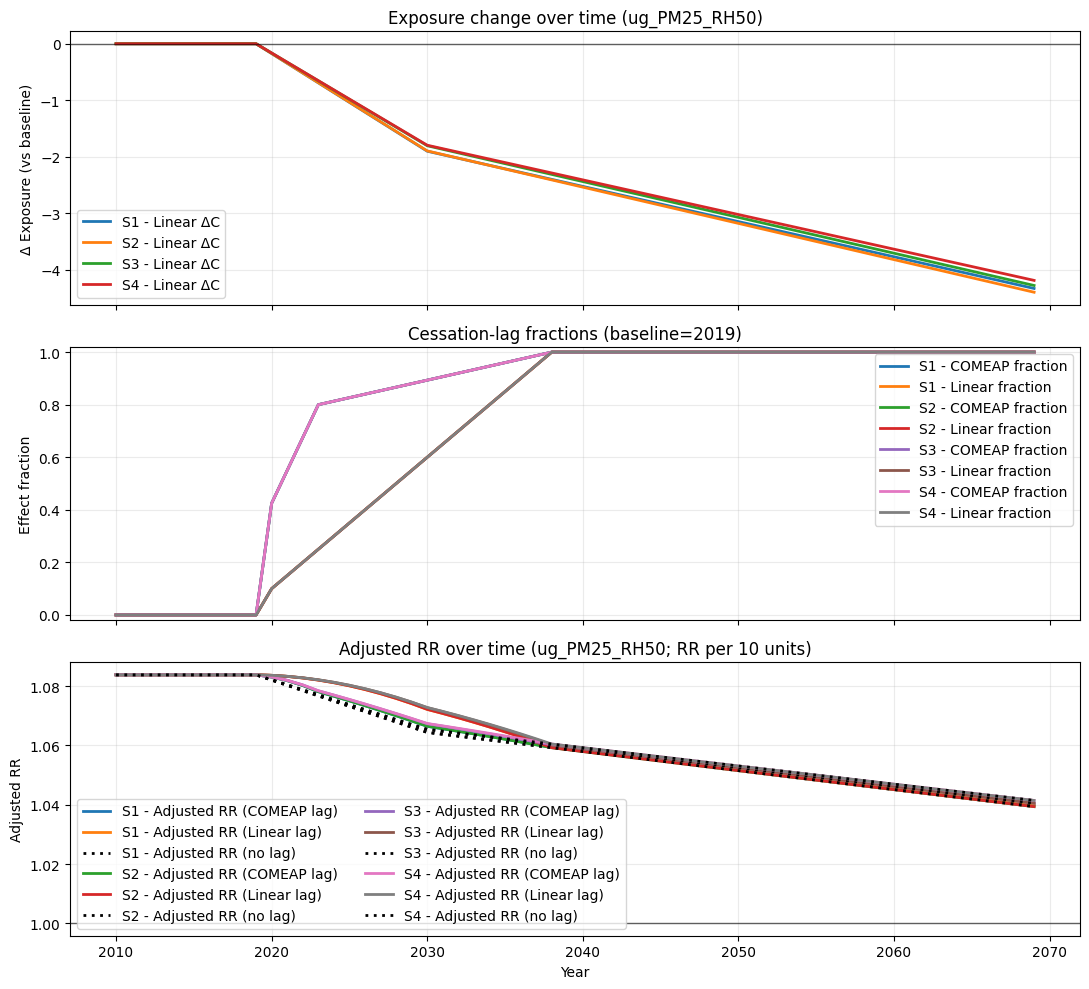

In [19]:
# Plot: (1) exposure change, (2) cessation-lag weights (effect fractions), (3) adjusted RR over time
# Task: For each scenario, plot both COMEAP and Linear-lag estimates for fractions and adjusted RR.
# --- Ensure columns used for plotting exist in rr_plot_df ---
if "delta_c_year_linear" not in rr_plot_df.columns:
    if "baseline_exposure_mean" in rr_plot_df.columns and "exposure_mean_linear" in rr_plot_df.columns:
        rr_plot_df = rr_plot_df.copy()
        rr_plot_df["delta_c_year_linear"] = (
                rr_plot_df["exposure_mean_linear"].astype(float) - rr_plot_df["baseline_exposure_mean"].astype(float)
        )
    elif "exposure_mean_linear" in rr_plot_df.columns:
        rr_plot_df = rr_plot_df.copy()
        _base = (
            rr_plot_df.loc[rr_plot_df["year"].astype(int) == int(BASELINE_YEAR)]
            .groupby(["scenario", "pollutant"])["exposure_mean_linear"]
            .mean()
        )
        rr_plot_df["delta_c_year_linear"] = rr_plot_df.apply(
            lambda r: float(r["exposure_mean_linear"]) - float(_base.loc[(r["scenario"], r["pollutant"])]),
            axis=1,
        )

_required_plot_cols = [
    "scenario",
    "pollutant",
    "year",
    "delta_c_year_linear",
    "frac_comeap",
    "frac_linear",
    "rr_adj_linear_comeap",
    "rr_adj_linear_linlag",
    "rr_change_linear_no_lag",
    "rr_adj_no_lag",
]

_missing_plot_cols = [c for c in _required_plot_cols if c not in rr_plot_df.columns]
if _missing_plot_cols:
    raise KeyError(
        "Plotting column(s) missing from rr_plot_df: "
        f"{_missing_plot_cols}\nAvailable columns: {list(rr_plot_df.columns)}"
    )

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
ax0, ax1, ax2 = axes

scenario_list = scenarios if "scenarios" in globals() and len(scenarios) else rr_plot_df["scenario"].unique().tolist()
pollutant_to_plot = pollutants[0] if "pollutants" in globals() and len(pollutants) else rr_plot_df["pollutant"].iloc[0]

for scenario in scenario_list:
    sub = (
        rr_plot_df[(rr_plot_df["scenario"] == scenario) & (rr_plot_df["pollutant"] == pollutant_to_plot)]
        .sort_values("year")
        .copy()
    )
    if sub.empty:
        continue

    # ----------------------------
    # (1) Exposure change vs baseline (linear exposure trajectory interpolated)
    # ----------------------------
    ax0.plot(
        sub["year"],
        sub["delta_c_year_linear"],
        linewidth=2,
        label=f"{scenario.upper()} - Linear ΔC",
    )

    # ----------------------------
    # (2) Cessation-lag cumulative fractions (COMEAP vs Linear)
    # ----------------------------
    ax1.plot(
        sub["year"],
        sub["frac_comeap"],
        linewidth=2,
        linestyle="-",
        label=f"{scenario.upper()} - COMEAP fraction",
    )
    ax1.plot(
        sub["year"],
        sub["frac_linear"],
        linewidth=2,
        linestyle="-",
        label=f"{scenario.upper()} - Linear fraction",
    )

    # ----------------------------
    # (3) Adjusted RR series (COMEAP vs Linear lag; both based on linear exposure)
    #     + No-lag reference series as dotted black lines
    # ----------------------------
    ax2.plot(
        sub["year"],
        sub["rr_adj_linear_comeap"],
        linewidth=2,
        linestyle="-",
        label=f"{scenario.upper()} - Adjusted RR (COMEAP lag)",
    )
    ax2.plot(
        sub["year"],
        sub["rr_adj_linear_linlag"],
        linewidth=2,
        linestyle="-",
        label=f"{scenario.upper()} - Adjusted RR (Linear lag)",
    )
    ax2.plot(
        sub["year"],
        sub["rr_adj_no_lag"],
        color="black",
        linewidth=2,
        linestyle=(0, (1, 2)),
        label=f"{scenario.upper()} - Adjusted RR (no lag)",
    )

# --- Formatting ---
ax0.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax0.set_title(f"Exposure change over time ({pollutant_to_plot})")
ax0.set_ylabel("Δ Exposure (vs baseline)")
ax0.grid(True, alpha=0.25)
ax0.legend(ncol=1)

ax1.set_title(f"Cessation-lag fractions (baseline={BASELINE_YEAR})")
ax1.set_ylabel("Effect fraction")
ax1.set_ylim(-0.02, 1.02)
ax1.grid(True, alpha=0.25)
ax1.legend(ncol=1)

ax2.axhline(1.0, color="black", linewidth=1, alpha=0.6)
ax2.set_title(f"Adjusted RR over time ({pollutant_to_plot}; RR per {UNIT_CHANGE:g} units)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Adjusted RR")
ax2.grid(True, alpha=0.25)
ax2.legend(ncol=2)

plt.tight_layout()
plt.show()


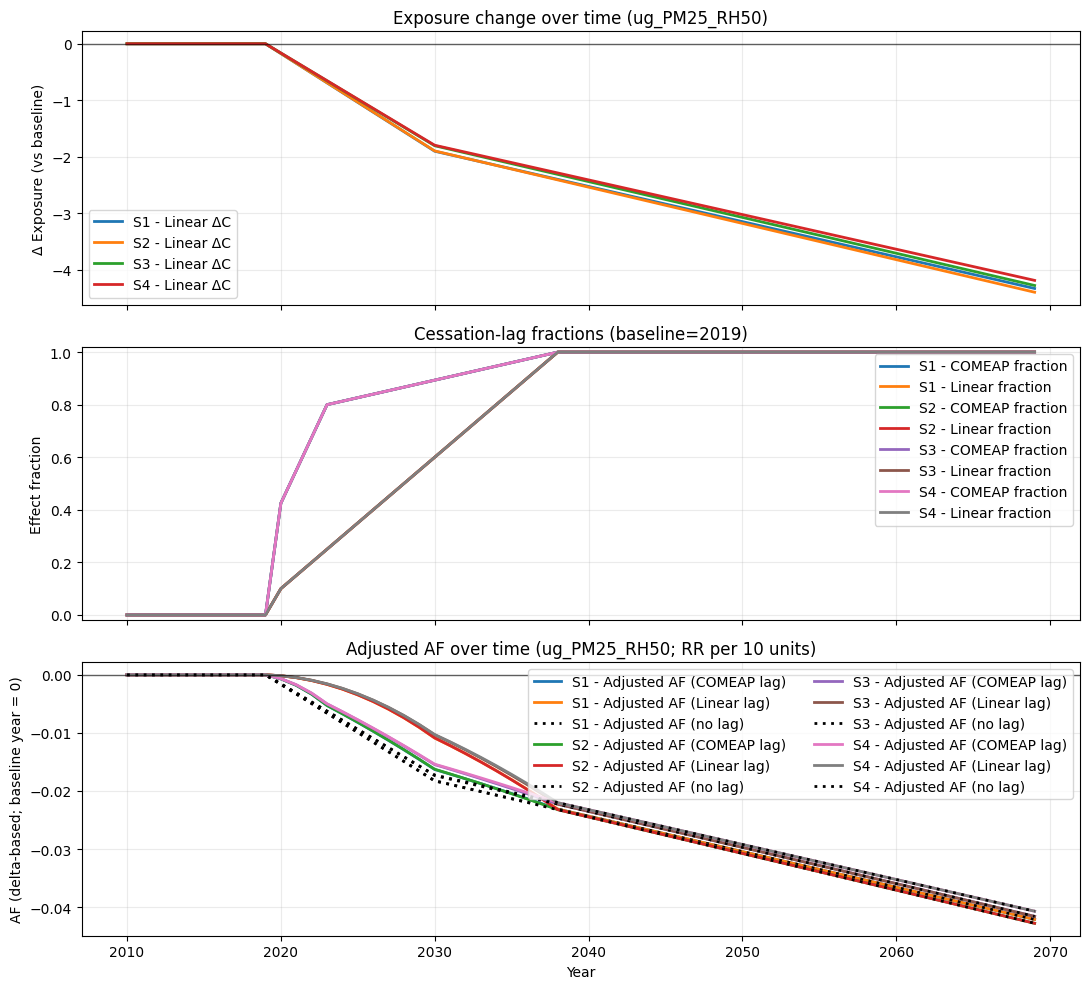

In [20]:
# Plot: (1) exposure change, (2) cessation-lag weights (effect fractions), (3) adjusted AF over time
# Task: For each scenario, plot both COMEAP and Linear-lag estimates for fractions and adjusted AF.
# This version plots AF instead of RR. It expects the AF columns created earlier:
#   - af_delta_no_lag
#   - af_delta_lag_comeap
#   - af_delta_lag_linear
#
# If those columns do not exist, it will compute them from:
#   - rr_per_unit
#   - delta_c_year_linear
#   - rr_change_adj_comeap / rr_change_adj_linear (or, if not present, from rr_adj_* and rr_base_abs if available)


# --- Ensure columns used for plotting exist in rr_plot_df ---
if "delta_c_year_linear" not in rr_plot_df.columns:
    if "baseline_exposure_mean" in rr_plot_df.columns and "exposure_mean_linear" in rr_plot_df.columns:
        rr_plot_df = rr_plot_df.copy()
        rr_plot_df["delta_c_year_linear"] = (
            rr_plot_df["exposure_mean_linear"].astype(float) - rr_plot_df["baseline_exposure_mean"].astype(float)
        )
    elif "exposure_mean_linear" in rr_plot_df.columns:
        rr_plot_df = rr_plot_df.copy()
        _base = (
            rr_plot_df.loc[rr_plot_df["year"].astype(int) == int(BASELINE_YEAR)]
            .groupby(["scenario", "pollutant"])["exposure_mean_linear"]
            .mean()
        )
        rr_plot_df["delta_c_year_linear"] = rr_plot_df.apply(
            lambda r: float(r["exposure_mean_linear"]) - float(_base.loc[(r["scenario"], r["pollutant"])]),
            axis=1,
        )


def _af_from_delta(rr_per_unit: np.ndarray, delta_c: np.ndarray, unit_change: float) -> np.ndarray:
    rr_per_unit = np.asarray(rr_per_unit, dtype=float)
    delta_c = np.asarray(delta_c, dtype=float)
    return 1.0 - np.exp(-np.log(rr_per_unit) * (delta_c / float(unit_change)))


# --- Compute AF columns if missing ---
need_af_cols = ["af_delta_no_lag", "af_delta_lag_comeap", "af_delta_lag_linear"]
missing_af_cols = [c for c in need_af_cols if c not in rr_plot_df.columns]
if missing_af_cols:
    # We can compute AF(no lag) directly from rr_per_unit and deltaC
    required_for_af = ["rr_per_unit", "delta_c_year_linear"]
    missing_for_af = [c for c in required_for_af if c not in rr_plot_df.columns]
    if missing_for_af:
        raise KeyError(
            "Cannot compute AF columns because these columns are missing from rr_plot_df: "
            f"{missing_for_af}\nAvailable columns: {list(rr_plot_df.columns)}"
        )

    rr_plot_df = rr_plot_df.copy()

    # No-lag AF (delta-based)
    rr_plot_df["af_delta_no_lag"] = _af_from_delta(
        rr_per_unit=rr_plot_df["rr_per_unit"].to_numpy(dtype=float),
        delta_c=rr_plot_df["delta_c_year_linear"].to_numpy(dtype=float),
        unit_change=UNIT_CHANGE,
    )

    # For lagged AF, we want lagged effective deltaC.
    # Best source is rr_change_adj_* (RR-change series, baseline-normalized) if present.
    # If they are not present, we fall back to using rr_adj_* divided by baseline-year rr_adj_* (per scenario/pollutant),
    # which reconstructs the RR-change series.
    if "rr_change_adj_comeap" in rr_plot_df.columns and "rr_change_adj_linear" in rr_plot_df.columns:
        rr_change_adj_comeap = rr_plot_df["rr_change_adj_comeap"].to_numpy(dtype=float)
        rr_change_adj_linear = rr_plot_df["rr_change_adj_linear"].to_numpy(dtype=float)
    else:
        # reconstruct RR-change as rr_adj_* / rr_adj_* at BASELINE_YEAR (within scenario+pollutant)
        needed_rr_cols = ["rr_adj_linear_comeap", "rr_adj_linear_linlag", "year", "scenario", "pollutant"]
        missing_rr_cols = [c for c in needed_rr_cols if c not in rr_plot_df.columns]
        if missing_rr_cols:
            raise KeyError(
                "Cannot compute lagged AF because rr_change_adj_* is missing and cannot reconstruct from rr_adj_* "
                f"(missing {missing_rr_cols}). Available columns: {list(rr_plot_df.columns)}"
            )

        # baseline rr for each (scenario, pollutant)
        base_rr = (
            rr_plot_df.loc[rr_plot_df["year"].astype(int) == int(BASELINE_YEAR)]
            .set_index(["scenario", "pollutant"])["rr_adj_no_lag"]
        )

        def _rr_change_from_abs(row, col_abs):
            return float(row[col_abs]) / float(base_rr.loc[(row["scenario"], row["pollutant"])])

        rr_change_adj_comeap = rr_plot_df.apply(lambda r: _rr_change_from_abs(r, "rr_adj_linear_comeap"), axis=1).to_numpy(dtype=float)
        rr_change_adj_linear = rr_plot_df.apply(lambda r: _rr_change_from_abs(r, "rr_adj_linear_linlag"), axis=1).to_numpy(dtype=float)

    # invert deltaC from RR-change: deltaC = UNIT_CHANGE * log(rr_change) / log(rr_per_unit)
    # (avoid division by zero if rr_per_unit == 1.0)
    log_rrpu = np.log(rr_plot_df["rr_per_unit"].to_numpy(dtype=float))
    if np.any(np.isclose(log_rrpu, 0.0)):
        raise ValueError("rr_per_unit contains 1.0 (log=0), cannot invert deltaC from rr_change.")

    delta_c_lag_comeap = UNIT_CHANGE * np.log(rr_change_adj_comeap) / log_rrpu
    delta_c_lag_linear = UNIT_CHANGE * np.log(rr_change_adj_linear) / log_rrpu

    rr_plot_df["af_delta_lag_comeap"] = _af_from_delta(
        rr_per_unit=rr_plot_df["rr_per_unit"].to_numpy(dtype=float),
        delta_c=delta_c_lag_comeap,
        unit_change=UNIT_CHANGE,
    )
    rr_plot_df["af_delta_lag_linear"] = _af_from_delta(
        rr_per_unit=rr_plot_df["rr_per_unit"].to_numpy(dtype=float),
        delta_c=delta_c_lag_linear,
        unit_change=UNIT_CHANGE,
    )

# --- Validate required plot cols ---
_required_plot_cols = [
    "scenario",
    "pollutant",
    "year",
    "delta_c_year_linear",
    "frac_comeap",
    "frac_linear",
    "af_delta_lag_comeap",
    "af_delta_lag_linear",
    "af_delta_no_lag",
]

_missing_plot_cols = [c for c in _required_plot_cols if c not in rr_plot_df.columns]
if _missing_plot_cols:
    raise KeyError(
        "Plotting column(s) missing from rr_plot_df: "
        f"{_missing_plot_cols}\nAvailable columns: {list(rr_plot_df.columns)}"
    )

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
ax0, ax1, ax2 = axes

scenario_list = scenarios if "scenarios" in globals() and len(scenarios) else rr_plot_df["scenario"].unique().tolist()
pollutant_to_plot = pollutants[0] if "pollutants" in globals() and len(pollutants) else rr_plot_df["pollutant"].iloc[0]

for scenario in scenario_list:
    sub = (
        rr_plot_df[(rr_plot_df["scenario"] == scenario) & (rr_plot_df["pollutant"] == pollutant_to_plot)]
        .sort_values("year")
        .copy()
    )
    if sub.empty:
        continue

    # ----------------------------
    # (1) Exposure change vs baseline (linear exposure trajectory interpolated)
    # ----------------------------
    ax0.plot(
        sub["year"],
        sub["delta_c_year_linear"],
        linewidth=2,
        label=f"{scenario.upper()} - Linear ΔC",
    )

    # ----------------------------
    # (2) Cessation-lag cumulative fractions (COMEAP vs Linear)
    # ----------------------------
    ax1.plot(
        sub["year"],
        sub["frac_comeap"],
        linewidth=2,
        linestyle="-",
        label=f"{scenario.upper()} - COMEAP fraction",
    )
    ax1.plot(
        sub["year"],
        sub["frac_linear"],
        linewidth=2,
        linestyle="-",
        label=f"{scenario.upper()} - Linear fraction",
    )

    # ----------------------------
    # (3) Adjusted AF series (COMEAP vs Linear lag; both based on linear exposure)
    #     + No-lag reference series as dotted black lines
    # ----------------------------
    ax2.plot(
        sub["year"],
        sub["af_delta_lag_comeap"],
        linewidth=2,
        linestyle="-",
        label=f"{scenario.upper()} - Adjusted AF (COMEAP lag)",
    )
    ax2.plot(
        sub["year"],
        sub["af_delta_lag_linear"],
        linewidth=2,
        linestyle="-",
        label=f"{scenario.upper()} - Adjusted AF (Linear lag)",
    )
    ax2.plot(
        sub["year"],
        sub["af_delta_no_lag"],
        color="black",
        linewidth=2,
        linestyle=(0, (1, 2)),
        label=f"{scenario.upper()} - Adjusted AF (no lag)",
    )

# --- Formatting ---
ax0.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax0.set_title(f"Exposure change over time ({pollutant_to_plot})")
ax0.set_ylabel("Δ Exposure (vs baseline)")
ax0.grid(True, alpha=0.25)
ax0.legend(ncol=1)

ax1.set_title(f"Cessation-lag fractions (baseline={BASELINE_YEAR})")
ax1.set_ylabel("Effect fraction")
ax1.set_ylim(-0.02, 1.02)
ax1.grid(True, alpha=0.25)
ax1.legend(ncol=1)

ax2.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax2.set_title(f"Adjusted AF over time ({pollutant_to_plot}; RR per {UNIT_CHANGE:g} units)")
ax2.set_xlabel("Year")
ax2.set_ylabel("AF (delta-based; baseline year = 0)")
ax2.grid(True, alpha=0.25)
ax2.legend(ncol=2)

plt.tight_layout()
plt.show()

In [21]:
# ---- Compute avoided-AF multipliers and save to CSV ----
# Multiplier definition (AF-based; consistent with AF health impact pipeline):
#   annual multiplier = avoided_lag / avoided_no_lag
#   cumulative multiplier = cumulative avoided_lag / cumulative avoided_no_lag
#
# where avoided is defined from AF as:
#   avoided(t) = AF_baseline - AF_scenario(t)
#
# IMPORTANT:
# - With your AF sign convention (AF = 1 - exp(-beta * ΔC)), exposure reductions (ΔC < 0)
#   yield AF < 0 (a "benefit"). Using avoided = AF_baseline - AF_scenario makes benefit positive.
# - Baseline year must be selected explicitly (BASELINE_YEAR), not by array index 0 (which is 2010).
#
# This code expects rr_plot_df to contain:
#   - af_delta_no_lag
#   - af_delta_lag_comeap
# If missing, it will compute them from rr_per_unit and delta_c_year_linear.

import os
import numpy as np

base_path = "data/2-output-data/Cessation_lags"
os.makedirs(base_path, exist_ok=True)


def _af_from_delta(rr_per_unit: np.ndarray, delta_c: np.ndarray, unit_change: float) -> np.ndarray:
    rr_per_unit = np.asarray(rr_per_unit, dtype=float)
    delta_c = np.asarray(delta_c, dtype=float)
    return 1.0 - np.exp(-np.log(rr_per_unit) * (delta_c / float(unit_change)))


# Ensure delta_c_year_linear exists (same logic as your plot block)
if "delta_c_year_linear" not in rr_plot_df.columns:
    if "baseline_exposure_mean" in rr_plot_df.columns and "exposure_mean_linear" in rr_plot_df.columns:
        rr_plot_df = rr_plot_df.copy()
        rr_plot_df["delta_c_year_linear"] = (
            rr_plot_df["exposure_mean_linear"].astype(float) - rr_plot_df["baseline_exposure_mean"].astype(float)
        )
    elif "exposure_mean_linear" in rr_plot_df.columns:
        rr_plot_df = rr_plot_df.copy()
        _base = (
            rr_plot_df.loc[rr_plot_df["year"].astype(int) == int(BASELINE_YEAR)]
            .groupby(["scenario", "pollutant"])["exposure_mean_linear"]
            .mean()
        )
        rr_plot_df["delta_c_year_linear"] = rr_plot_df.apply(
            lambda r: float(r["exposure_mean_linear"]) - float(_base.loc[(r["scenario"], r["pollutant"])]),
            axis=1,
        )

# Ensure AF columns exist; compute if missing
af_needed = ["af_delta_no_lag", "af_delta_lag_comeap"]
missing_af = [c for c in af_needed if c not in rr_plot_df.columns]
if missing_af:
    required = ["rr_per_unit", "delta_c_year_linear"]
    missing_required = [c for c in required if c not in rr_plot_df.columns]
    if missing_required:
        raise KeyError(
            f"Missing columns needed to compute AF: {missing_required}. "
            f"Available: {list(rr_plot_df.columns)}"
        )

    rr_plot_df = rr_plot_df.copy()

    # no-lag AF directly from deltaC
    rr_plot_df["af_delta_no_lag"] = _af_from_delta(
        rr_per_unit=rr_plot_df["rr_per_unit"].to_numpy(dtype=float),
        delta_c=rr_plot_df["delta_c_year_linear"].to_numpy(dtype=float),
        unit_change=UNIT_CHANGE,
    )

    # lagged AF: prefer existing af_delta_lag_comeap; otherwise reconstruct from RR-change if available,
    # otherwise reconstruct RR-change from absolute RR relative to baseline year.
    if "rr_change_adj_comeap" in rr_plot_df.columns:
        rr_change_adj_comeap = rr_plot_df["rr_change_adj_comeap"].to_numpy(dtype=float)
    else:
        # reconstruct RR-change using absolute RR series divided by baseline year absolute RR (by scenario/pollutant)
        needed_rr = ["rr_adj_linear_comeap", "rr_adj_no_lag", "year", "scenario", "pollutant"]
        missing_needed_rr = [c for c in needed_rr if c not in rr_plot_df.columns]
        if missing_needed_rr:
            raise KeyError(
                "Cannot compute lagged AF: rr_change_adj_comeap is missing and cannot reconstruct from rr_adj_* "
                f"(missing {missing_needed_rr}). Available: {list(rr_plot_df.columns)}"
            )

        base_rr = (
            rr_plot_df.loc[rr_plot_df["year"].astype(int) == int(BASELINE_YEAR)]
            .set_index(["scenario", "pollutant"])["rr_adj_no_lag"]
        )

        def _rr_change_from_abs(row):
            return float(row["rr_adj_linear_comeap"]) / float(base_rr.loc[(row["scenario"], row["pollutant"])])

        rr_change_adj_comeap = rr_plot_df.apply(_rr_change_from_abs, axis=1).to_numpy(dtype=float)

    # invert deltaC from RR-change:
    #   rr_change = exp(log(rr_per_unit) * deltaC / UNIT_CHANGE)
    #   => deltaC = UNIT_CHANGE * log(rr_change) / log(rr_per_unit)
    log_rrpu = np.log(rr_plot_df["rr_per_unit"].to_numpy(dtype=float))
    if np.any(np.isclose(log_rrpu, 0.0)):
        raise ValueError("rr_per_unit contains 1.0 (log=0), cannot invert deltaC from rr_change.")

    delta_c_lag_comeap = UNIT_CHANGE * np.log(rr_change_adj_comeap) / log_rrpu

    rr_plot_df["af_delta_lag_comeap"] = _af_from_delta(
        rr_per_unit=rr_plot_df["rr_per_unit"].to_numpy(dtype=float),
        delta_c=delta_c_lag_comeap,
        unit_change=UNIT_CHANGE,
    )

# ---- Export multipliers per scenario ----
for scenario in scenario_list:
    sub = (
        rr_plot_df[
            (rr_plot_df["scenario"] == scenario)
            & (rr_plot_df["pollutant"] == pollutant_to_plot)
        ]
        .sort_values("year")
        .copy()
    )

    if sub.empty:
        continue

    # -------------------------------------------------------
    # 1. Extract AF series (delta-based; baseline-normalized)
    # -------------------------------------------------------
    af_lag = sub["af_delta_lag_comeap"].to_numpy(dtype=float)
    af_no_lag = sub["af_delta_no_lag"].to_numpy(dtype=float)

    # -------------------------------------------------------
    # 2. Define baseline AF explicitly at BASELINE_YEAR
    # -------------------------------------------------------
    if int(BASELINE_YEAR) not in sub["year"].astype(int).values:
        raise ValueError(f"BASELINE_YEAR={BASELINE_YEAR} is missing in sub for scenario={scenario}, pollutant={pollutant_to_plot}")

    af_baseline = float(sub.loc[sub["year"].astype(int) == int(BASELINE_YEAR), "af_delta_no_lag"].iloc[0])

    # For delta-based AF, this should be ~0.0 by construction.
    # Keep it explicit to avoid hidden assumptions.
    # -------------------------------------------------------
    # 3. Compute avoided AF relative to baseline
    #    avoided = AF_baseline - AF_scenario
    #    With your sign convention, reductions give AF_scenario < 0 => avoided > 0.
    # -------------------------------------------------------
    avoided_no_lag = af_baseline - af_no_lag
    avoided_lag = af_baseline - af_lag

    # Prevent tiny negative floating-point noise
    avoided_no_lag = np.maximum(avoided_no_lag, 0.0)
    avoided_lag = np.maximum(avoided_lag, 0.0)

    # -------------------------------------------------------
    # 4. Annual multiplier (lagged benefit / immediate benefit)
    # -------------------------------------------------------
    annual_multiplier = np.where(
        avoided_no_lag > 0.0,
        avoided_lag / avoided_no_lag,
        np.nan,
    )

    # -------------------------------------------------------
    # 5. Cumulative multipliers
    # -------------------------------------------------------
    cum_avoided_no_lag = np.cumsum(avoided_no_lag)
    cum_avoided_lag = np.cumsum(avoided_lag)

    cumulative_multiplier = np.where(
        cum_avoided_no_lag > 0.0,
        cum_avoided_lag / cum_avoided_no_lag,
        np.nan,
    )

    # -------------------------------------------------------
    # 6. Export DataFrame
    # -------------------------------------------------------
    export_cols = [
        "scenario",
        "pollutant",
        "year",
        "exposure_mean_linear",
        "delta_c_year_linear",
        # RR columns kept for traceability (optional)
        "rr_adj_no_lag",
        "rr_adj_linear_comeap",
        # AF columns used for multipliers
        "af_delta_no_lag",
        "af_delta_lag_comeap",
    ]

    missing_export = [c for c in export_cols if c not in sub.columns]
    if missing_export:
        raise KeyError(
            f"Missing export columns in rr_plot_df: {missing_export}\nAvailable columns: {list(sub.columns)}"
        )

    export_df = sub[export_cols].copy()

    export_df["af_baseline"] = af_baseline
    export_df["avoided_af_no_lag"] = avoided_no_lag
    export_df["avoided_af_lag_comeap"] = avoided_lag
    export_df["annual_multiplier_lag_over_no_lag"] = annual_multiplier
    export_df["cumulative_avoided_af_no_lag"] = cum_avoided_no_lag
    export_df["cumulative_avoided_af_lag_comeap"] = cum_avoided_lag
    export_df["cumulative_multiplier_lag_over_no_lag"] = cumulative_multiplier

    out_csv = (
        f"multiplier_lag_v_no_lag_AVOIDED__"
        f"{scenario}_{pollutant_to_plot}_2010_2070.csv"
    )

    out_csv_path = os.path.join(base_path, out_csv)
    export_df.to_csv(out_csv_path, index=False)

    print(f"Saved AF multiplier CSV: {out_csv_path}")

Saved AF multiplier CSV: data/2-output-data/Cessation_lags\multiplier_lag_v_no_lag_AVOIDED__s1_ug_PM25_RH50_2010_2070.csv
Saved AF multiplier CSV: data/2-output-data/Cessation_lags\multiplier_lag_v_no_lag_AVOIDED__s2_ug_PM25_RH50_2010_2070.csv
Saved AF multiplier CSV: data/2-output-data/Cessation_lags\multiplier_lag_v_no_lag_AVOIDED__s3_ug_PM25_RH50_2010_2070.csv
Saved AF multiplier CSV: data/2-output-data/Cessation_lags\multiplier_lag_v_no_lag_AVOIDED__s4_ug_PM25_RH50_2010_2070.csv


C:\Users\aysharma\AppData\Local\Temp\ipykernel_12856\462463427.py:158: RuntimeWarning: invalid value encountered in divide
  avoided_lag / avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_12856\462463427.py:170: RuntimeWarning: invalid value encountered in divide
  cum_avoided_lag / cum_avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_12856\462463427.py:158: RuntimeWarning: invalid value encountered in divide
  avoided_lag / avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_12856\462463427.py:170: RuntimeWarning: invalid value encountered in divide
  cum_avoided_lag / cum_avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_12856\462463427.py:158: RuntimeWarning: invalid value encountered in divide
  avoided_lag / avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel_12856\462463427.py:170: RuntimeWarning: invalid value encountered in divide
  cum_avoided_lag / cum_avoided_no_lag,
C:\Users\aysharma\AppData\Local\Temp\ipykernel

In [11]:
#Lag comparison for S2 scenarios
import warnings
import logging
import numpy as np
import pandas as pd
#Helper codes
def _validate_anchor_years(anchor_years):
    anchor_years = sorted(set(int(y) for y in anchor_years))
    if len(anchor_years) < 2:
        raise ValueError("Need at least two anchor years to interpolate.")
    return anchor_years

def _resolve_rr_key(pollutant_key, rr_map):
    k = str(pollutant_key).strip()
    if k in rr_map:
        return k

    kl = k.lower()
    for kk in rr_map.keys():
        if str(kk).strip().lower() == kl:
            return kk

    raise KeyError(f"{pollutant_key} not found in RR_MORTALITY_MAP. Available: {list(rr_map.keys())}")
# -----------------------------
# Setup
# -----------------------------
warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

scenarios = ["s2"]
pollutants = ["ug_NO2"] #"ug_PM25_RH50"
years = list(range(2010, 2070))
ANCHOR_YEARS = [2019, 2030, 2050]

UNIT_CHANGE = 10.0
BASELINE_YEAR = int(globals().get("LAG_BASE_YEAR", 2019))
LAG_YEARS_SET = [5, 10, 20, 35]

# -----------------------------
# CRS alignment (unchanged)
# -----------------------------
target_crs = donnees_exportees_transformed.crs
donnees_exportees_transformed = donnees_exportees_transformed.to_crs(target_crs)
grille_combinee = grille_combinee.to_crs(target_crs)

# -----------------------------
# Pre-compute masks
# -----------------------------
years_arr = np.asarray(years, dtype=int)
mask_pre = years_arr <= BASELINE_YEAR

plot_rows = []

# -----------------------------
# Main loop
# -----------------------------
for scenario in scenarios:
    for pollutant in pollutants:

        # --- RR info ---
        rr_key = _resolve_rr_key(pollutant, RR_MORTALITY_MAP_Main)
        rr_per_unit, _, _ = RR_MORTALITY_MAP_Main[rr_key]
        rr_per_unit = float(rr_per_unit)

        # --- Exposure interpolation ---
        expo_cache = build_exposure_cache_for_anchors(
            scenario, pollutant,
            donnees_exportees_transformed, grille_combinee
        )
        anchor_means = exposure_mean_from_cache(expo_cache, pollutant)
        expo_linear = np.asarray(
            interpolate_exposure_means_linear(years, anchor_means),
            dtype=float
        )

        # --- Baseline exposure ---
        base_idx = years.index(BASELINE_YEAR)
        base_expo = float(anchor_means.get(BASELINE_YEAR, expo_linear[base_idx]))
        expo_linear[mask_pre] = base_expo

        # --- Baseline absolute RR ---
        rr_base_abs = rr_from_exposure_change(
            exposure_year=base_expo,
            exposure_base=None,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )

        # --- RR change relative to baseline ---
        rr_change_linear = rr_from_exposure_change(
            exposure_year=expo_linear,
            exposure_base=base_expo,
            rr_per_unit=rr_per_unit,
            unit_change=UNIT_CHANGE,
        )

        # -----------------------------
        # Loop over lag assumptions
        # -----------------------------
        for lag_years in LAG_YEARS_SET:

            _, frac_comeap, _, frac_linear = generate_cessation_lag_fractions(
                base_year=BASELINE_YEAR,
                eval_years=years,
                lag_years=lag_years,
            )

            frac_comeap = np.asarray(frac_comeap, dtype=float)
            frac_linear = np.asarray(frac_linear, dtype=float)
            frac_comeap[mask_pre] = 0.0
            frac_linear[mask_pre] = 0.0

            rr_adj_comeap = rr_base_abs * adjusted_rr_with_cessation_lag(
                rr_change_linear, frac_comeap
            )
            rr_adj_linear = rr_base_abs * adjusted_rr_with_cessation_lag(
                rr_change_linear, frac_linear
            )
            rr_adj_no_lag = rr_base_abs * rr_change_linear

            for i, y in enumerate(years):
                plot_rows.append({
                    "scenario": scenario,
                    "pollutant": pollutant,
                    "year": int(y),
                    "lag_years": int(lag_years),
                    "rr_adj_no_lag": float(rr_adj_no_lag[i]),
                    "rr_adj_linear_comeap": float(rr_adj_comeap[i]),
                    "rr_adj_linear_linlag": float(rr_adj_linear[i]),
                })

# -----------------------------
# Final DataFrame
# -----------------------------
rr_plot_df = pd.DataFrame(plot_rows)

INFO:root:[ANCHOR] Computing exposure: Scenario=s2, Pollutant=ug_NO2, Year=2019


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_ineris function


INFO:root:Starting optimized expo function
INFO:root:Expo processing completed successfully
INFO:root:[ANCHOR] Computing exposure: Scenario=s2, Pollutant=ug_NO2, Year=2030


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS2_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_ineris function


INFO:root:Starting optimized expo function
INFO:root:Expo processing completed successfully
INFO:root:[ANCHOR] Computing exposure: Scenario=s2, Pollutant=ug_NO2, Year=2050


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS2_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_ineris function


INFO:root:Starting optimized expo function
INFO:root:Expo processing completed successfully


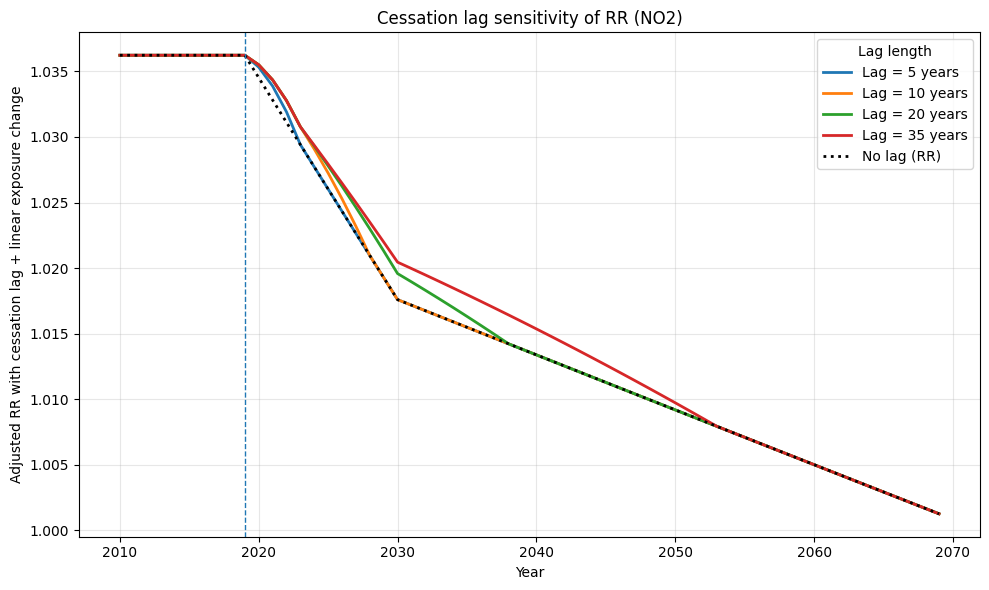

In [12]:
import matplotlib.pyplot as plt
#senstivity plot with different lags (5,10,20,35)
plot_df = (
    rr_plot_df.sort_values(["lag_years", "year"])
)

plt.figure(figsize=(10, 6))
for lag, g in plot_df.groupby("lag_years"):
    plt.plot(
        g["year"],
        g["rr_adj_linear_comeap"],
        label=f"Lag = {lag} years",
        linewidth=2,
    )

g0 = plot_df.sort_values("year").drop_duplicates(subset=["year"], keep="first")
plt.plot(
    g0["year"],
    g0["rr_adj_no_lag"],
    color="black",
    linestyle=":",
    linewidth=2,
    label="No lag (RR)",
)
plt.axvline(BASELINE_YEAR, linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Adjusted RR with cessation lag + linear exposure change")
plt.title("Cessation lag sensitivity of RR (NO2)")
plt.legend(title="Lag length")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


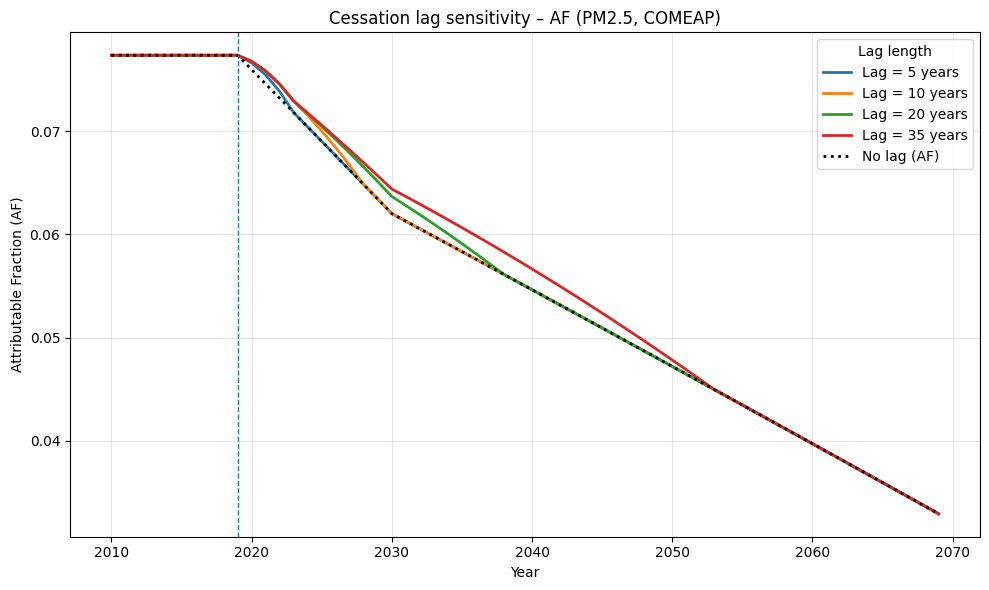

In [19]:
import matplotlib.pyplot as plt
#senstivity plot with different lags (5,10,20,35) but with AF
plot_df = (
    rr_plot_df
    .assign(
        AF=lambda d: (d["rr_adj_linear_comeap"] - 1.0) / d["rr_adj_linear_comeap"],
        AF_no_lag=lambda d: (d["rr_adj_no_lag"] - 1.0) / d["rr_adj_no_lag"],
    )
    .sort_values(["lag_years", "year"])
)

plt.figure(figsize=(10, 6))

for lag, g in plot_df.groupby("lag_years"):
    plt.plot(
        g["year"],
        g["AF"],
        label=f"Lag = {lag} years",
        linewidth=2,
    )

g0 = plot_df.sort_values("year").drop_duplicates(subset=["year"], keep="first")
plt.plot(
    g0["year"],
    g0["AF_no_lag"],
    color="black",
    linestyle=":",
    linewidth=2,
    label="No lag (AF)",
)

plt.axvline(BASELINE_YEAR, linestyle="--", linewidth=1)
plt.xlabel("Year")
plt.ylabel("Attributable Fraction (AF)")
plt.title("Cessation lag sensitivity – AF (PM2.5, COMEAP)")
plt.legend(title="Lag length")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
